## Imporing libraries to be used...

In [157]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from scipy.stats import shapiro
from statsmodels.stats.stattools import jarque_bera

## Since, our data is in a csv file, we are converting it into a pandas series so that it can be worked upon easily..

In [158]:
def convert_csv_to_series(data):
    pd_data=pd.read_csv(data)
    pd_series=pd_data.set_index("Date")
    cols = list(pd_series.columns)
    original_name=cols[0]
    cols[0] = 'Close'
    pd_series.columns = cols
    return pd_series,original_name

## This is a function which converts the stock prices into the log returns...

In [159]:
def convert_prices_to_log_return(data):
    pd_series,name=convert_csv_to_series(data)[0],convert_csv_to_series(data)[1]
    pd_series["log_returns"]=np.log(pd_series['Close'] / pd_series['Close'].shift(1))
    return pd_series["log_returns"].dropna().to_frame(),name

## Defining a reusable function for creating the histogram

In [160]:
def create_histogram(data):
    sns.histplot(data, kde=True)
    plt.title("Histogram with KDE")
    plt.xlabel("Values")
    plt.ylabel("Frequency")
    plt.show()
    

## For Q-Q Plot

In [161]:
def create_QQ_plot(data):
    data = data.squeeze()       
    data = data.dropna() 
    stats.probplot(data, dist="norm", plot=plt)
    plt.title("Q-Q Plot")
    plt.show()

## For normality check using shapiro-wilk test 

In [162]:

def shapiro_test(data):
    data=data['log_returns']
    data = np.asarray(data).flatten()     
    data = data[~np.isnan(data)]          
    
    stat, p_value = shapiro(data)
    
    print("Shapiro-Wilk Test")
    print(f"Statistic: {stat:.4f}")
    print(f"p-value: {p_value:.4f}")
    
    if p_value > 0.05:
        print("Conclusion: Data looks NORMAL ")
    else:
        print("Conclusion: Data is NOT normal ")
    
   

## for normality test using JB test

In [163]:
def jb_test(data):
    data=data['log_returns']
    data = np.asarray(data).flatten()
    data = data[~np.isnan(data)]
    
    jb_stat, p_value, skew, kurtosis = jarque_bera(data)
    
    print("Jarque-Bera Test")
    print(f"JB Statistic: {jb_stat:.4f}")
    print(f"p-value: {p_value:.4f}")
    print(f"Skewness: {skew:.4f}")
    print(f"Kurtosis: {kurtosis:.4f}")
    
    if p_value > 0.05:
        print("Conclusion: Normal distribution ")
    else:
        print("Conclusion: Not normal ")
    
    

## For plotting the time series data for the log returns

In [1]:
def plot_data(data):
    
    name=data[1]
    df = data[0] 
    
    df.index = pd.to_datetime(df.index)
    
    plt.figure(figsize=(10,6))
    plt.plot(df)
    plt.xlabel("Time Period")
    plt.ylabel("log returns")
    plt.title(f'Time series data of log returns of {name}')
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.grid()

    plt.xticks(rotation=45)
    plt.show()
    


## This function combined the entire previous functions in a single, reusable pipeline

In [165]:
def normality_check(data):
    name=data[1]
    df=data[0]
    
    
    print(f'Stock ticker is : {name}\n')
    min_date=df.index[0]
    max_date=df.index[-1]
    print(f"The duration of data is from {min_date} to {max_date}\n")
    
    print("Some data points are as follows: ")
    print(df.head())
    print("\n")
    
    print("Desciption of data: \n")
    print(df.describe())
    print("\n")
    
    
    print("Plotting the series: \n")
    plot_data(data)
    
   
    
    print("Plotting the hiostogram with the kernel density: ")
    create_histogram(df)
    
    print("Plotting the QQ plot: ")
    create_QQ_plot(df)
    
    print("Testing normal Saphiro-Wilk test: The results are as follows: ")
    shapiro_test(df)
    print("\n")
    
    print("Results of JB test: ")
    jb_test(df)

## Data (log returns)

In [166]:
nf50=convert_prices_to_log_return("nf_50_main.csv")
msft=convert_prices_to_log_return("microsoft_main.csv")
snp_500=convert_prices_to_log_return("snp_500_main.csv")
reliance=convert_prices_to_log_return("reliance_main.csv")
tcs=convert_prices_to_log_return("tcs_main.csv")
sbi=convert_prices_to_log_return("sbi_main.csv")

## Nifty 50 index

Stock ticker is : ^NSEI

The duration of data is from 2025-01-02 to 2025-12-31

Some data points are as follows: 
            log_returns
Date                   
2025-01-02     0.018600
2025-01-03    -0.007632
2025-01-06    -0.016325
2025-01-07     0.003882
2025-01-08    -0.000800


Desciption of data: 

       log_returns
count   248.000000
mean      0.000386
std       0.007440
min      -0.032970
25%      -0.003874
50%      -0.000030
75%       0.004694
max       0.037472


Plotting the series: 



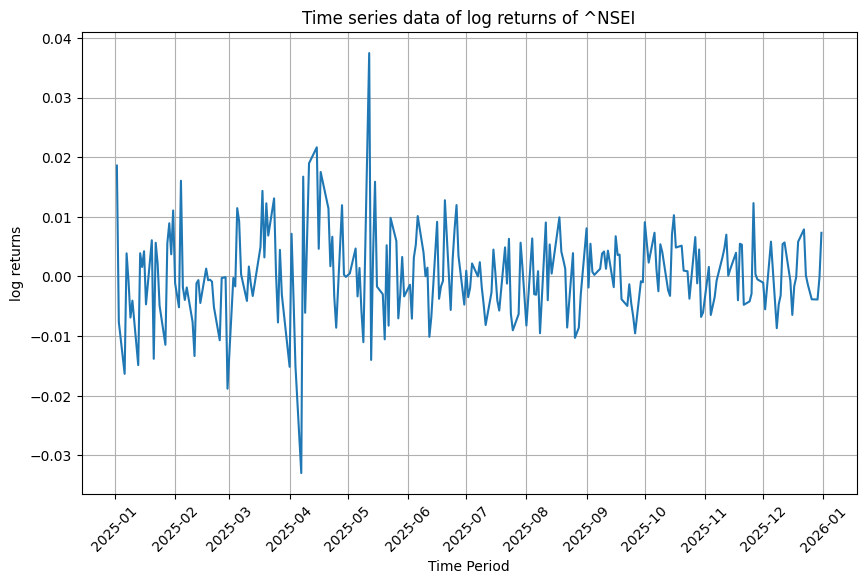

Plotting the hiostogram with the kernel density: 


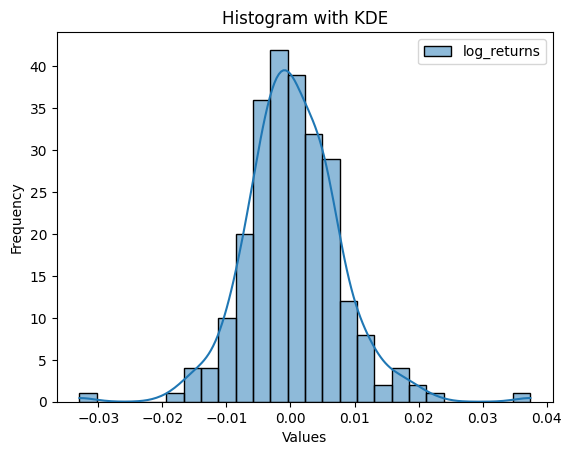

Plotting the QQ plot: 


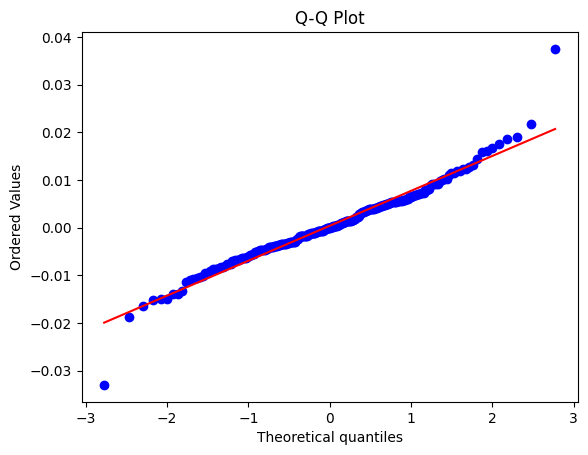

Testing normal Saphiro-Wilk test: The results are as follows: 
Shapiro-Wilk Test
Statistic: 0.9629
p-value: 0.0000
Conclusion: Data is NOT normal 


Results of JB test: 
Jarque-Bera Test
JB Statistic: 128.1969
p-value: 0.0000
Skewness: 0.2802
Kurtosis: 6.4774
Conclusion: Not normal 


In [167]:
normality_check(nf50)

## Microsoft

Stock ticker is : MSFT

The duration of data is from 2025-01-03 to 2025-12-31

Some data points are as follows: 
            log_returns
Date                   
2025-01-03     0.011331
2025-01-06     0.010573
2025-01-07    -0.012891
2025-01-08     0.005172
2025-01-10    -0.013302


Desciption of data: 

       log_returns
count   249.000000
mean      0.000610
std       0.015163
min      -0.063802
25%      -0.006135
50%       0.000780
75%       0.006120
max       0.096525


Plotting the series: 



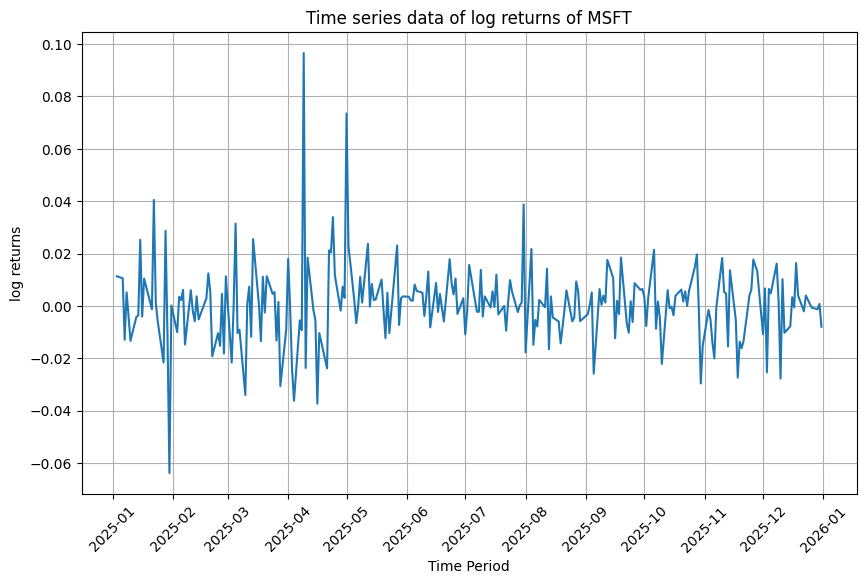

Plotting the hiostogram with the kernel density: 


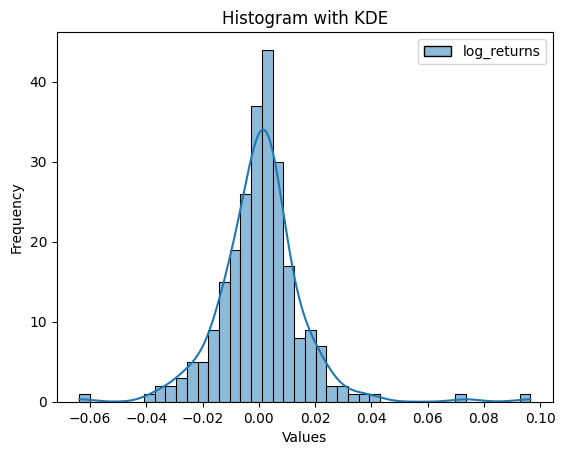

Plotting the QQ plot: 


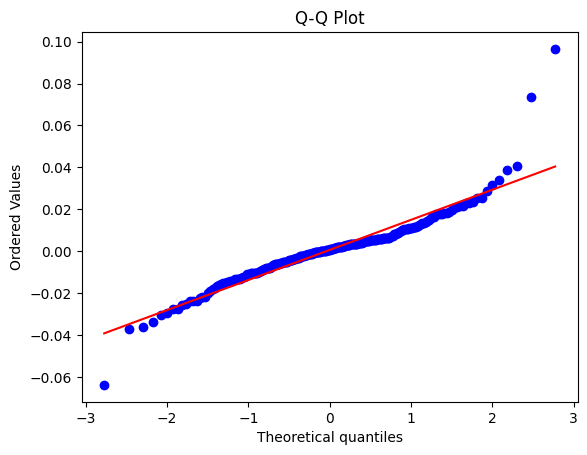

Testing normal Saphiro-Wilk test: The results are as follows: 
Shapiro-Wilk Test
Statistic: 0.8939
p-value: 0.0000
Conclusion: Data is NOT normal 


Results of JB test: 
Jarque-Bera Test
JB Statistic: 849.2543
p-value: 0.0000
Skewness: 1.0738
Kurtosis: 11.7888
Conclusion: Not normal 


In [168]:
normality_check(msft)

## S&P 500

Stock ticker is : ^GSPC

The duration of data is from 2025-01-03 to 2025-12-31

Some data points are as follows: 
            log_returns
Date                   
2025-01-03     0.012517
2025-01-06     0.005523
2025-01-07    -0.011166
2025-01-08     0.001559
2025-01-10    -0.015532


Desciption of data: 

       log_returns
count   249.000000
mean      0.000618
std       0.011769
min      -0.061609
25%      -0.003702
50%       0.001326
75%       0.005783
max       0.090895


Plotting the series: 



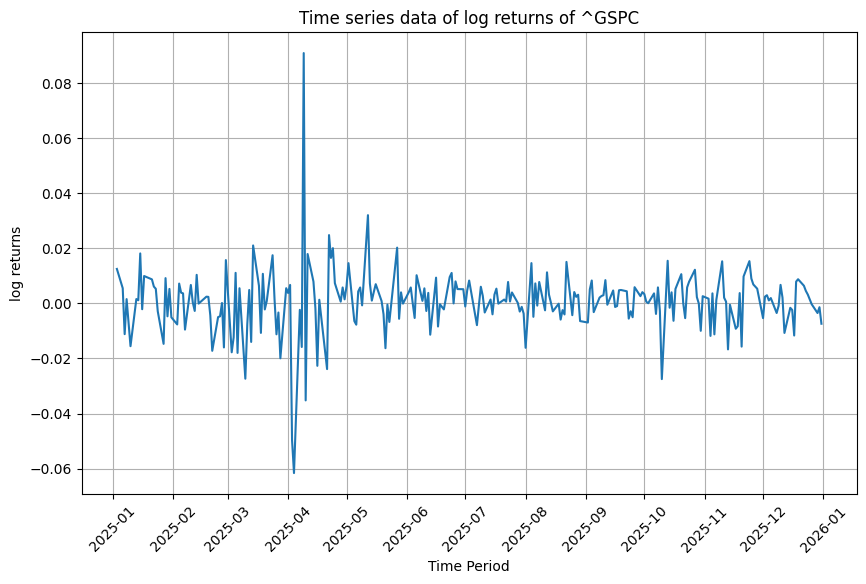

Plotting the hiostogram with the kernel density: 


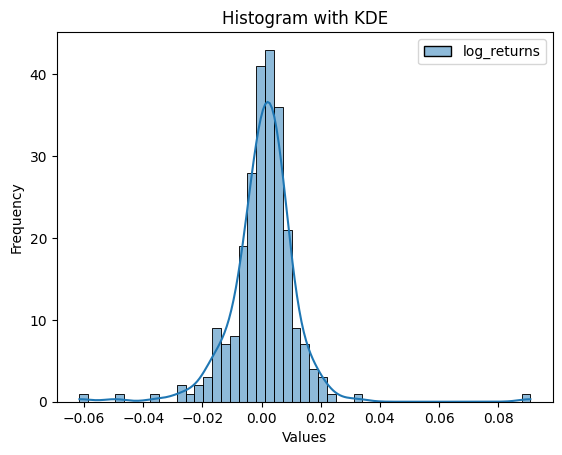

Plotting the QQ plot: 


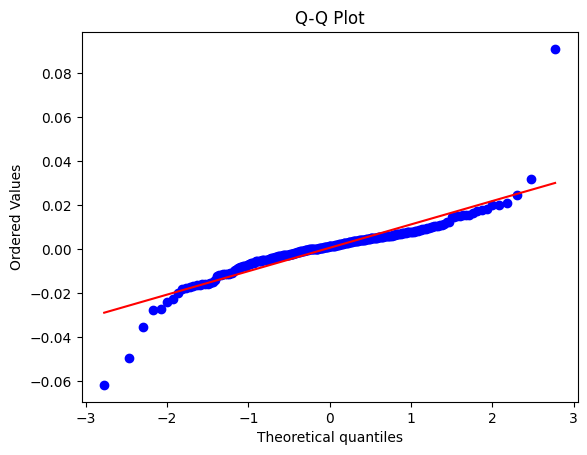

Testing normal Saphiro-Wilk test: The results are as follows: 
Shapiro-Wilk Test
Statistic: 0.8177
p-value: 0.0000
Conclusion: Data is NOT normal 


Results of JB test: 
Jarque-Bera Test
JB Statistic: 3067.5783
p-value: 0.0000
Skewness: 0.7231
Kurtosis: 20.1341
Conclusion: Not normal 


In [169]:
normality_check(snp_500)

## Reliance

Stock ticker is : RELIANCE.NS

The duration of data is from 2025-01-02 to 2025-12-31

Some data points are as follows: 
            log_returns
Date                   
2025-01-02     0.016687
2025-01-03     0.007501
2025-01-06    -0.026853
2025-01-07     0.018586
2025-01-08     0.019671


Desciption of data: 

       log_returns
count   248.000000
mean      0.001030
std       0.012263
min      -0.035873
25%      -0.006603
50%       0.000611
75%       0.007117
max       0.051263


Plotting the series: 



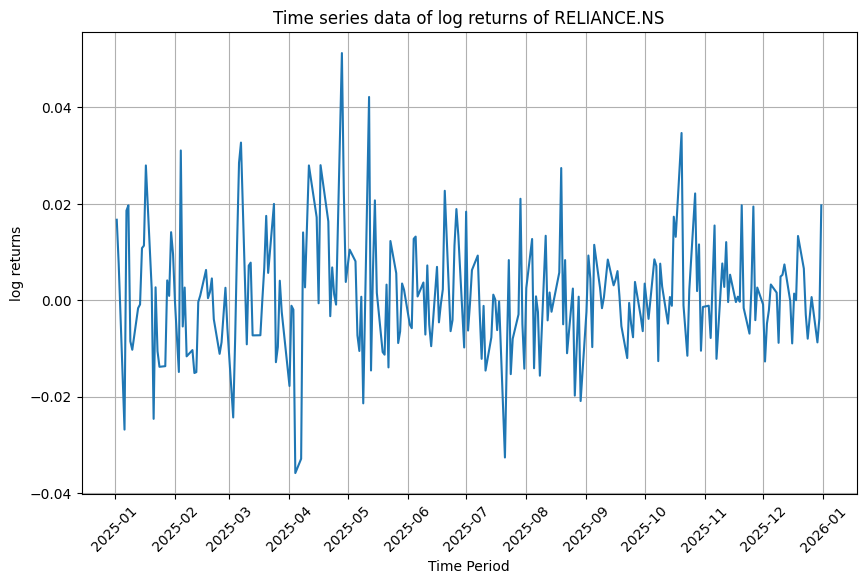

Plotting the hiostogram with the kernel density: 


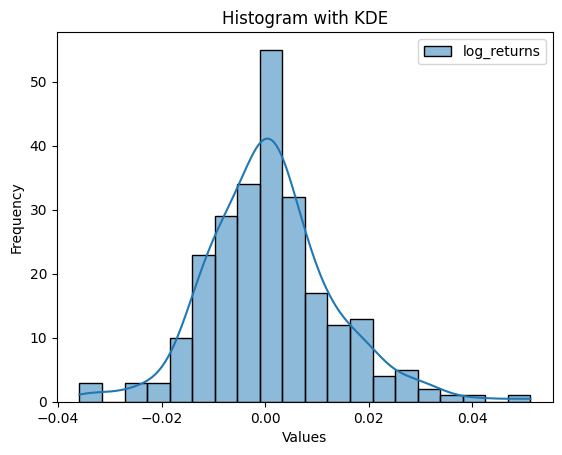

Plotting the QQ plot: 


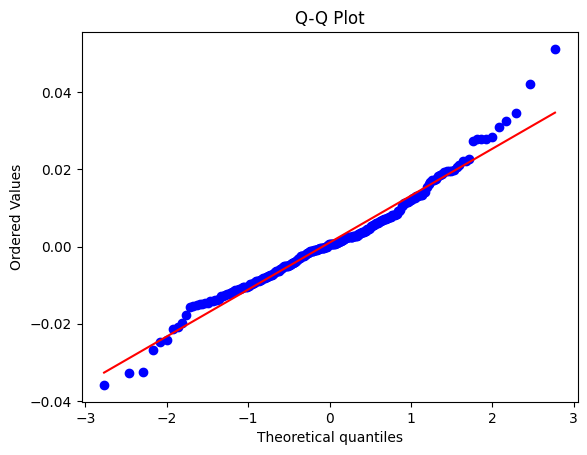

Testing normal Saphiro-Wilk test: The results are as follows: 
Shapiro-Wilk Test
Statistic: 0.9728
p-value: 0.0001
Conclusion: Data is NOT normal 


Results of JB test: 
Jarque-Bera Test
JB Statistic: 36.0952
p-value: 0.0000
Skewness: 0.4774
Kurtosis: 4.6066
Conclusion: Not normal 


In [170]:
normality_check(reliance)

## TCS

Stock ticker is : TCS.NS

The duration of data is from 2025-01-02 to 2025-12-31

Some data points are as follows: 
            log_returns
Date                   
2025-01-02     0.015275
2025-01-03    -0.018331
2025-01-06    -0.001196
2025-01-07    -0.016422
2025-01-08     0.019689


Desciption of data: 

       log_returns
count   248.000000
mean     -0.000866
std       0.012479
min      -0.040540
25%      -0.007720
50%      -0.001274
75%       0.005618
max       0.054635


Plotting the series: 



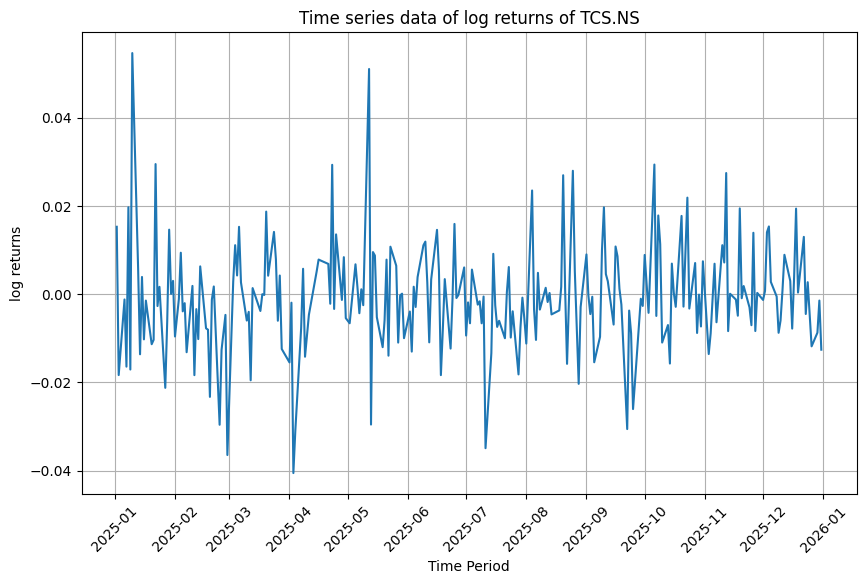

Plotting the hiostogram with the kernel density: 


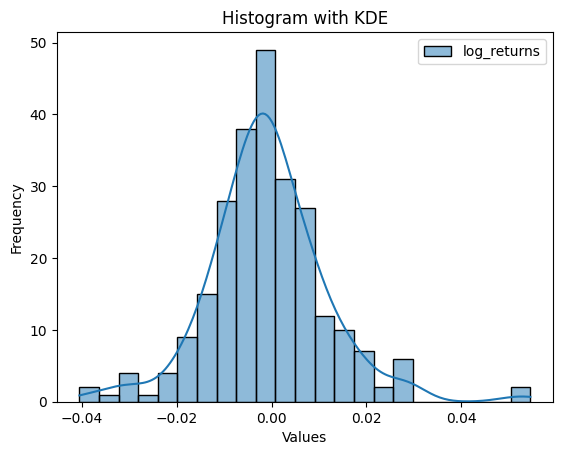

Plotting the QQ plot: 


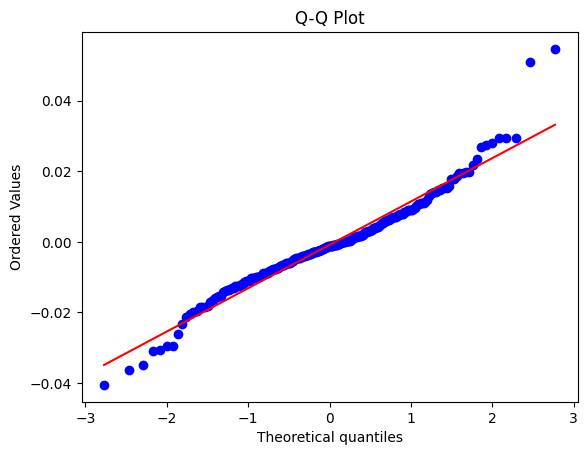

Testing normal Saphiro-Wilk test: The results are as follows: 
Shapiro-Wilk Test
Statistic: 0.9584
p-value: 0.0000
Conclusion: Data is NOT normal 


Results of JB test: 
Jarque-Bera Test
JB Statistic: 90.0327
p-value: 0.0000
Skewness: 0.4687
Kurtosis: 5.7989
Conclusion: Not normal 


In [171]:
normality_check(tcs)

Stock ticker is : SBIN.NS

The duration of data is from 2025-01-02 to 2025-12-31

Some data points are as follows: 
            log_returns
Date                   
2025-01-02     0.010035
2025-01-03    -0.009783
2025-01-06    -0.021660
2025-01-07     0.003022
2025-01-08    -0.009807


Desciption of data: 

       log_returns
count   248.000000
mean      0.000942
std       0.011298
min      -0.034952
25%      -0.006149
50%       0.000310
75%       0.006688
max       0.035988


Plotting the series: 



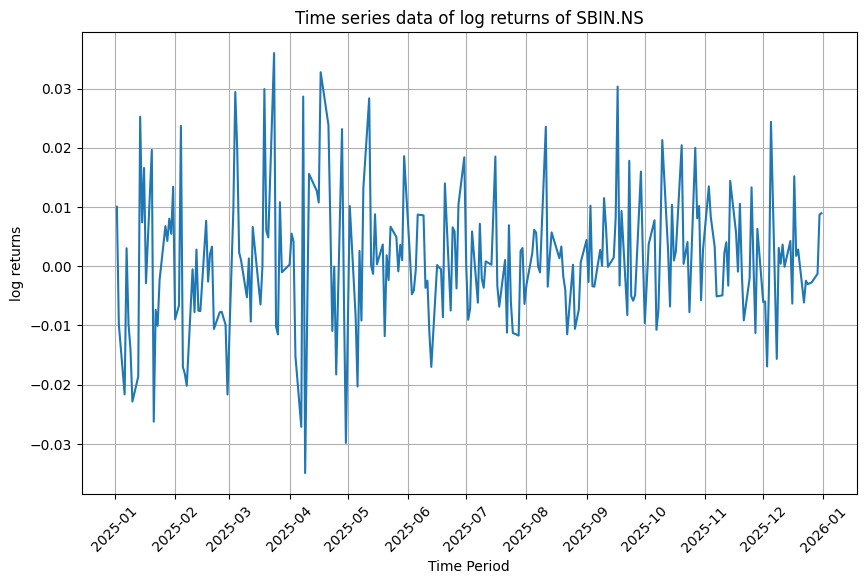

Plotting the hiostogram with the kernel density: 


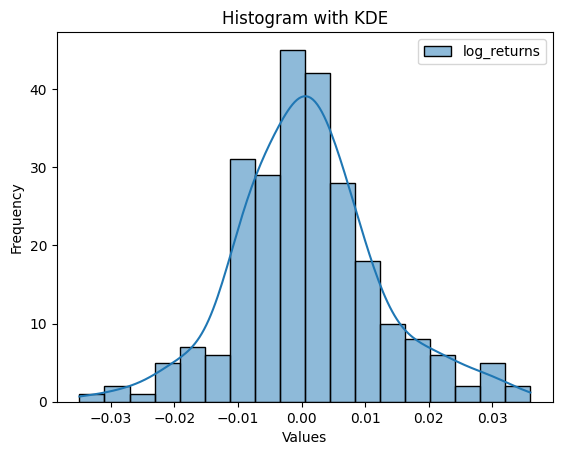

Plotting the QQ plot: 


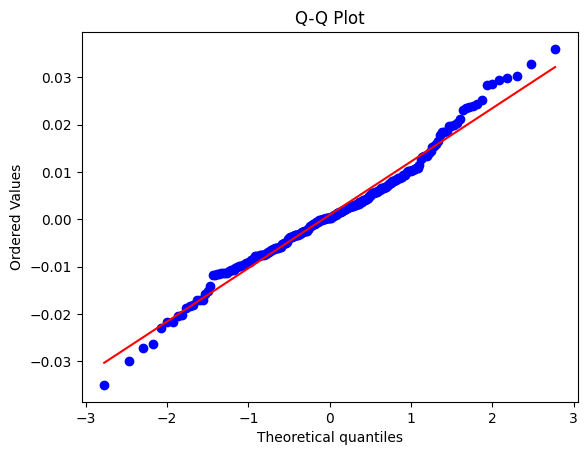

Testing normal Saphiro-Wilk test: The results are as follows: 
Shapiro-Wilk Test
Statistic: 0.9811
p-value: 0.0022
Conclusion: Data is NOT normal 


Results of JB test: 
Jarque-Bera Test
JB Statistic: 10.4221
p-value: 0.0055
Skewness: 0.2523
Kurtosis: 3.8684
Conclusion: Not normal 


In [172]:
normality_check(sbi)